# **NumPy, Pandas & Matplotlib Integration**

## About the Database
The Global Power Plant Database is an open-source dataset provided by the World Resources Institute, that compiles information on power plants worldwide. It includes about +30,000 plants across 167 countries, covering both thermal sources (coal, gas, oil, nuclear, biomass, etc.) and renewables (hydro, wind, and solar). Each plant is geolocated and includes data such as capacity, generation, ownership, and fuel type.

Topics:
Economy & Industry, Power Sector

Source:
https://datasets.wri.org/datasets/global-power-plant-database


In [31]:
#imports

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  #hypotesis test


# Import

In [32]:
uploaded = files.upload()

Saving global_power_plant_database.csv to global_power_plant_database (1).csv


In [33]:
df_raw = pd.read_csv('global_power_plant_database.csv', low_memory=False)

print(f'Size of dataset: {df_raw.shape[0]} power plants  x {df_raw.shape[1]} columns')

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nSummary: columns names, nulls and data types\n")
print(df_raw.info())

Size of dataset: 34936 power plants  x 36 columns

First 5 rows:


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1



Summary: columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null

In [34]:
# New DataFrame - Key column selection
df = df_raw[[
    "country_long",
    "capacity_mw",
    "latitude",
    "longitude",
    "primary_fuel",
    "commissioning_year",
    'owner'
]].copy()

print(f'Size of dataset: {df.shape[0]} power plants  x {df.shape[1]} columns')

print("\nFirst 5 plants:")
display(df.head())

print("\nSummary: columns names, nulls and data types\n")
print(df.info())

Size of dataset: 34936 power plants  x 7 columns

First 5 plants:


,country_long,capacity_mw,latitude,longitude,primary_fuel,commissioning_year,owner
0,Afghanistan,33.0,32.322,65.1190,Hydro,NaN,NaN
1,Afghanistan,10.0,31.670,65.7950,Solar,NaN,NaN
2,Afghanistan,10.0,31.623,65.7920,Solar,NaN,NaN
3,Afghanistan,66.0,34.556,69.4787,Hydro,NaN,NaN
4,Afghanistan,100.0,34.641,69.7170,Hydro,NaN,NaN



Summary: columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country_long        34936 non-null  object 
 1   capacity_mw         34936 non-null  float64
 2   latitude            34936 non-null  float64
 3   longitude           34936 non-null  float64
 4   primary_fuel        34936 non-null  object 
 5   commissioning_year  17447 non-null  float64
 6   owner               20868 non-null  object 
dtypes: float64(4), object(3)
memory usage: 1.9+ MB
None


# Cleaning

In [35]:
# == duplicates==

dup_count = df.duplicated().sum()
print(f"Duplicate rows before: {dup_count}")

# 131 duplicate records in the dataframe, they are deleted

df2 = df.drop_duplicates().copy()

dup_count = df2.duplicated().sum()
print(f"Duplicate rows after: {dup_count}")

Duplicate rows before: 103
Duplicate rows after: 0


In [36]:
# ==  missing values ==

missing_counts = df2.isnull().sum()
missing_pct = ((missing_counts / len(df2)) * 100).round(1)

missing_df2 = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).query("`Missing Count` > 0").sort_values(by='Missing %', ascending=False)

display(missing_df2)


,Missing Count,Missing %
commissioning_year,17439,50.1
owner,14024,40.3


In [37]:
# Treatment 40% missing in owner

# Replace NaN with description
df2['owner'] = df2['owner'].fillna('No Owner declared')

# Ensure type string
df2['owner'] = df2['owner'].astype('string')

missing_df2 = df2.isna().sum()
display(missing_df2)

,0
country_long,0
capacity_mw,0
latitude,0
longitude,0
primary_fuel,0
commissioning_year,17439
owner,0


In [38]:
# Commissioning_year  has 50% missing values.

# Variable will be retained, but time-series analyses will only be performed on records that DO have a year.

# Commissioning_year --> Convert to integer
df2["commissioning_year"] = pd.to_numeric(df2["commissioning_year"], errors="coerce").round().astype("Int64")   # For time series, it's advisable NOT to convert year to category.)

In [40]:
# -----------------------------
# Data Types Convertion
# -----------------------------

# categorical
categorical_cols = ["country_long", "primary_fuel"]
for col in categorical_cols:
    df2[col] = df2[col].astype("category")

# numerical
numeric_cols = ["capacity_mw", "latitude", "longitude"]
for col in numeric_cols:
    df2[col] = pd.to_numeric(df2[col], errors="coerce")

# #check data types
df2.dtypes


,0
country_long,category
capacity_mw,float64
latitude,float64
longitude,float64
primary_fuel,category
commissioning_year,Int64
owner,string[python]


In [41]:
# Exploration on years:

print("\nYear range:", df2["commissioning_year"].min(), "-", df2["commissioning_year"].max())
print("\nDescription:", df2["commissioning_year"].describe())  # very old plants dating from the late 19th century


Year range: 1896 - 2020

Description: count        17394.0
mean     1997.370013
std        23.413792
min           1896.0
25%           1988.0
50%           2007.0
75%           2014.0
max           2020.0
Name: commissioning_year, dtype: Float64


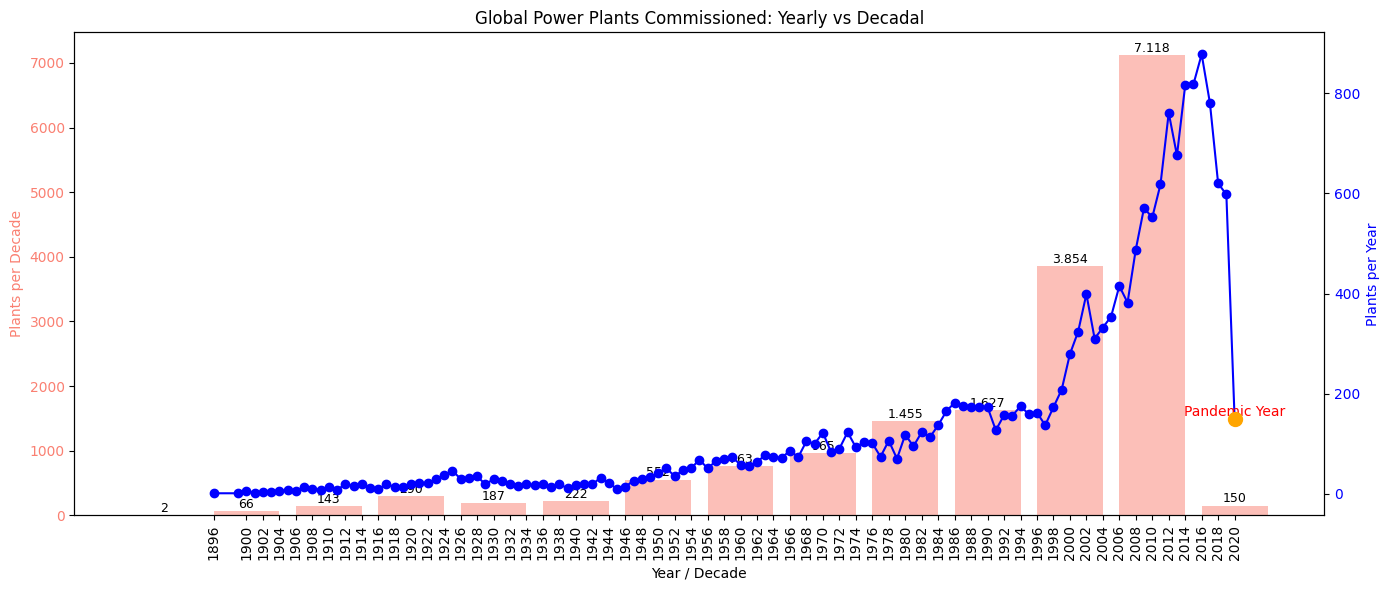

In [77]:
#Power Plants Growth Over Time

#decade
df2['decade'] = (df2['commissioning_year'] // 10) * 10

#count per year - per decade
plants_per_year = df2.groupby('commissioning_year').size().sort_index()
plants_per_decade = df2.groupby('decade').size().sort_index()

fig, ax1 = plt.subplots(figsize=(14,6))

# --- decade ---
bars = ax1.bar(plants_per_decade.index, plants_per_decade.values, width=8,
        color='salmon', alpha=0.5, label='Plants per Decade')
ax1.set_xlabel("Year / Decade")
ax1.set_ylabel("Plants per Decade", color='salmon')
ax1.tick_params(axis='y', labelcolor='salmon')
ax1.set_xticks(plants_per_year.index[::2])
ax1.set_xticklabels(plants_per_year.index[::2], rotation=90)

# --- numbes on bars ---
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height):,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=9
    )

# --- line for years ---
ax2 = ax1.twinx()
ax2.plot(plants_per_year.index, plants_per_year.values, color='blue', marker='o',
         label='Plants per Year')
ax2.set_ylabel("Plants per Year", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Note on pandemic year 2020 ---
if 2020 in plants_per_year.index:
    ax2.scatter(2020, plants_per_year[2020], color='orange', s=100, zorder=5)
    ax2.text(2020, plants_per_year[2020]+5, 'Pandemic Year', color='red', ha='center', fontsize=10)

plt.title("Global Power Plants Commissioned: Yearly vs Decadal")
fig.tight_layout()
plt.show()

The graph shows a steady growth since mid-20th century, with a notable acceleration starting in the 90s, reflecting the expansion of global demand and increased investment in renewable energy.

2020 stands out as completely atypical due to the pandemic, which interrupted the construction and commissioning of new plants, causing a temporary drop relative to the growth trend.

# Exploratory Data Analysis (EDA)

In [43]:
# ===========================================
# Check distributions
# ===========================================

# ---- summary statistics ----
display(df2.describe())
display(df2.describe(include='category'))

,capacity_mw,latitude,longitude,commissioning_year,decade
count,34833.000000,34833.000000,34833.000000,17394.0,17394.0
mean,163.634962,32.821884,-6.925816,1997.370013,1992.666437
std,490.239463,22.646738,78.403026,23.413792,23.326936
min,1.000000,-77.847000,-179.977700,1896.0,1890.0
25%,4.900000,29.271000,-77.633500,1988.0,1980.0
50%,16.800000,39.741900,-2.099400,2007.0,2000.0
75%,76.000000,46.275300,49.500000,2014.0,2010.0
max,22500.000000,71.292000,179.388700,2020.0,2020.0


,country_long,primary_fuel
count,34833,34833
unique,167,15
top,United States of America,Solar
freq,9794,10598


In [44]:
# == Key statistics for capacity ==

df2['capacity_mw'].describe().loc[['mean','50%','std']]


,capacity_mw
mean,163.634962
50%,16.800000
std,490.239463


The average capacity of the plants is about 164 MW, but the median of 16.8 MW indicates that most are relatively small. The high standard deviation reflects the existence of some extremely large plants that raise the average.

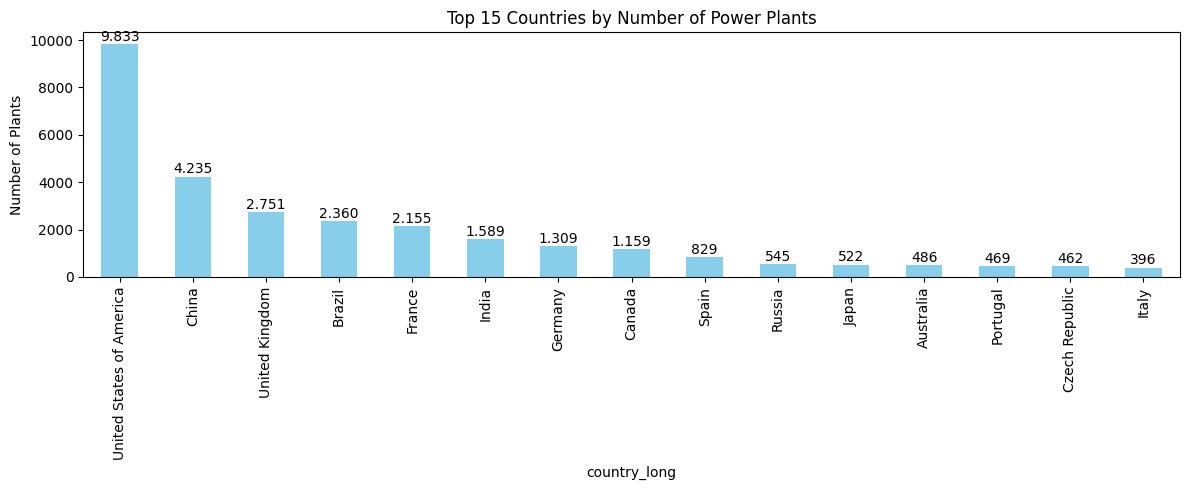

In [78]:
#Plant distribution by country

top_countries = df['country_long'].value_counts().head(15)

plt.figure(figsize=(12,5))
bars = top_countries.plot(kind='bar', color='skyblue')
plt.title("Top 15 Countries by Number of Power Plants")
plt.ylabel("Number of Plants")
plt.xticks(rotation=90)
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5, f"{int(bar.get_height()):,}".replace(',', '.'), ha='center', va='bottom')
plt.tight_layout()
plt.show()




Which fuel is dominant?


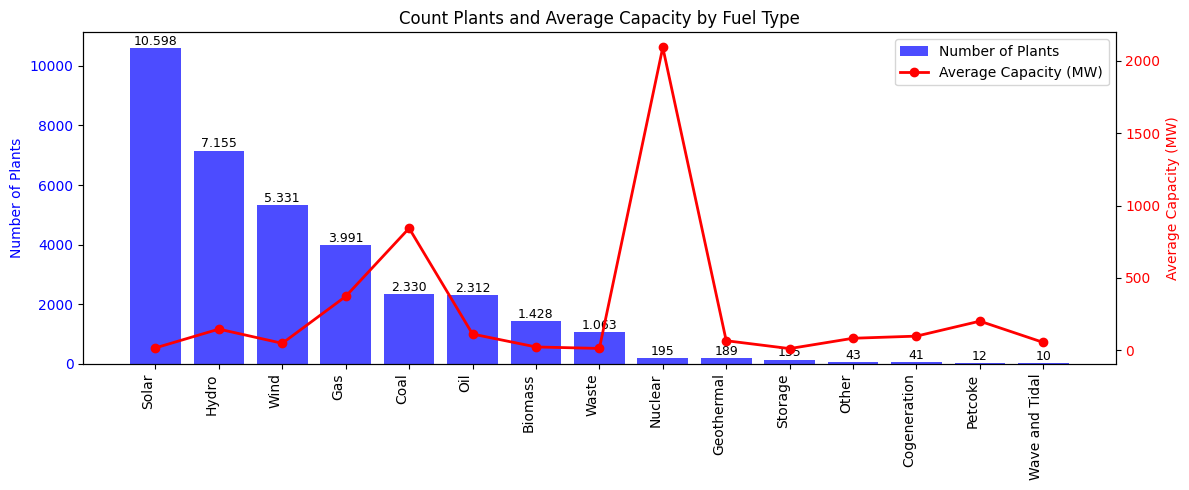

In [80]:
#Plant distribution by fuel type and power

print("\nWhich fuel is dominant?")

fuel_counts = df2['primary_fuel'].value_counts()
avg_capacity = df2.groupby("primary_fuel", observed=False)["capacity_mw"].mean()
avg_capacity = avg_capacity[fuel_counts.index]

fig, ax1 = plt.subplots(figsize=(12,5))

bars = ax1.bar(fuel_counts.index, fuel_counts.values, color='blue', alpha=0.7, label='Number of Plants')
ax1.set_ylabel("Number of Plants", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# numbers on top for bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height):,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=9
    )

# --- Line: average capacity ---
ax2 = ax1.twinx()
ax2.plot(avg_capacity.index, avg_capacity.values, color='red', marker='o', linewidth=2, label='Average Capacity (MW)')
ax2.set_ylabel("Average Capacity (MW)", color='red')
ax2.tick_params(axis='y', labelcolor='red')


ax1.set_xticks(range(len(fuel_counts)))
ax1.set_xticklabels(fuel_counts.index, rotation=90, ha='right')

# --- Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title("Count Plants and Average Capacity by Fuel Type")
fig.tight_layout()
plt.show()


Renovables (solar, wind, hydro) dominan en número de plantas;  pero carbón, gas y nuclear concentran mucha mayor capacidad promedio.

In [81]:
# Extreme Plants

percentile = (df2['capacity_mw'] <= 9000).mean() * 100
print(percentile)   #99.99

print('Plants with the highest maximum capacities')

largest_plants = df2[(df2['capacity_mw'] >= 9000)]

display(largest_plants[['country_long', 'primary_fuel', 'capacity_mw', 'commissioning_year', 'owner']])

#The largest plants are hydroelectric in China; we don't know who owns them.

99.99138747739212
Plants with the highest maximum capacities


,country_long,primary_fuel,capacity_mw,commissioning_year,owner
5137,China,Hydro,13050.0,<NA>,No Owner declared
8453,China,Hydro,22500.0,2003,No Owner declared
8755,China,Hydro,12600.0,2013,No Owner declared


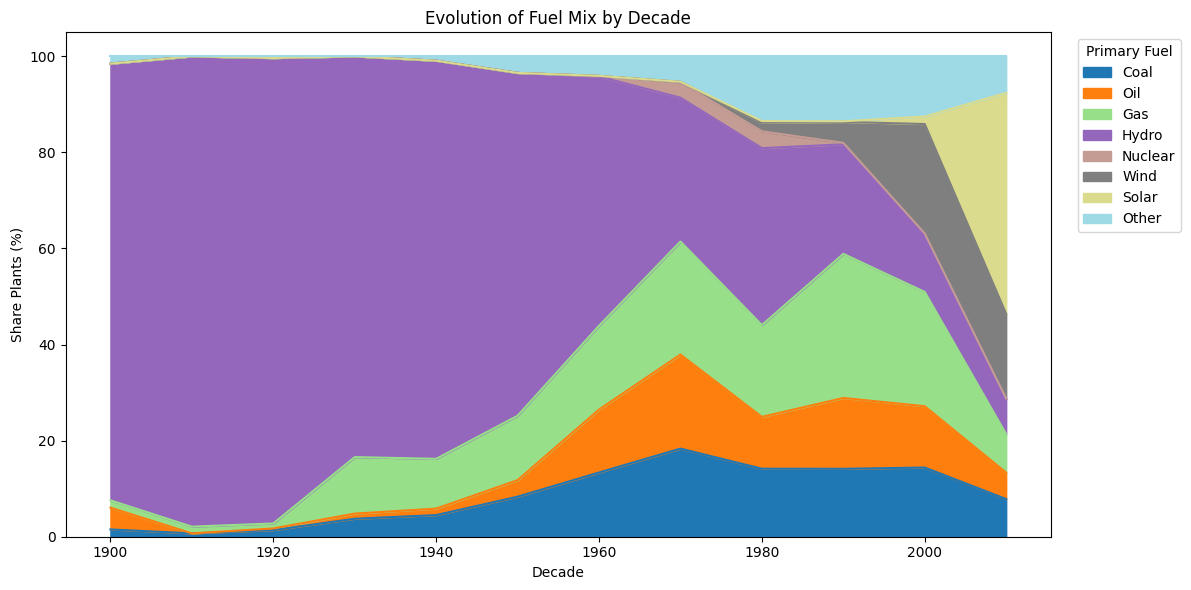

In [83]:
# Evolution of Fuel Mix by Decade

# Centuries XX - XXI
df_filtered = df2[(df2['decade'] >= 1900) & (df2['decade'] < 2020)].copy()

# Group smaller fuels
main_fuels = ['Coal','Gas','Hydro','Nuclear','Oil','Solar','Wind']

df_filtered['fuel_grouped'] = np.where(
    df_filtered['primary_fuel'].isin(main_fuels),
    df_filtered['primary_fuel'],
    'Other'
)

mix_by_decade = (
    df_filtered
    .groupby(['decade','fuel_grouped'])
    .size()
    .unstack(fill_value=0)
)

mix_share = mix_by_decade.div(mix_by_decade.sum(axis=1), axis=0) * 100


order = ['Coal','Oil','Gas','Hydro','Nuclear','Wind','Solar','Other']
mix_share = mix_share.reindex(columns=[c for c in order if c in mix_share.columns])


mix_share.plot(kind='area', stacked=True, figsize=(12,6), cmap='tab20')

plt.title("Evolution of Fuel Mix by Decade")
plt.ylabel("Share Plants (%)")
plt.xlabel("Decade")
plt.xticks(rotation=0)
plt.legend(title="Primary Fuel", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()



Structural changes in the global energy system.

* Growth in gas from the 1970s–1990s.

* Gradual reduction in hydropower.

* Nuclear: small share.

* Strong entry of renewables in recent decades (explosion in wind and solar).

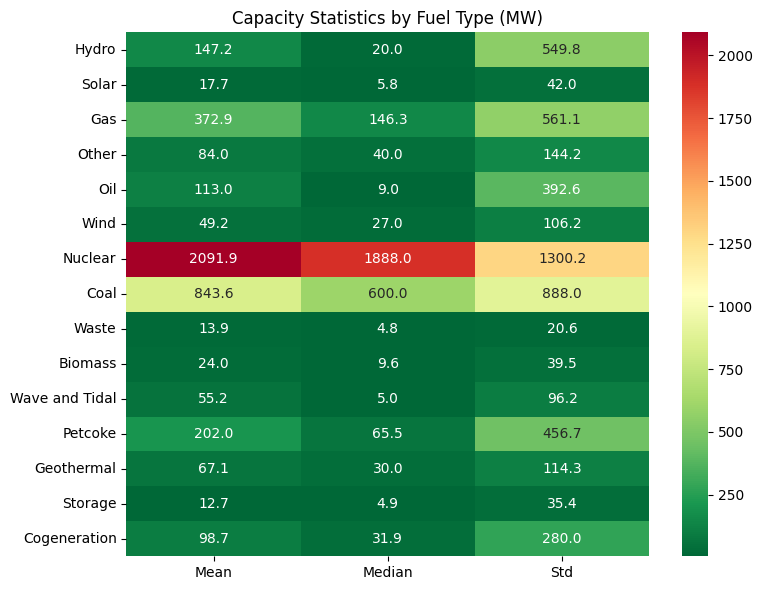

In [87]:
# Statistical Analysis – Capacity by Fuel

fuel_groups = {fuel: df2[df2['primary_fuel']==fuel]['capacity_mw'].dropna().values for fuel in df['primary_fuel'].unique()}
fuels = list(fuel_groups.keys())
stats_matrix = np.column_stack([
    [np.mean(v) for v in fuel_groups.values()],
    [np.median(v) for v in fuel_groups.values()],
    [np.std(v) for v in fuel_groups.values()]
])

plt.figure(figsize=(8,6))
sns.heatmap(stats_matrix, annot=True, fmt=".1f", cmap="RdYlGn_r", xticklabels=["Mean","Median","Std"], yticklabels=fuels)
plt.title("Capacity Statistics by Fuel Type (MW)")
plt.tight_layout()
plt.show()

Nuclear technology is concentrated in large-capacity plants, while modern renewable technologies have more distributed and smaller-scale facilities.

The high standard deviation for some fuels suggests significant variability in plant sizes.

In [ ]:
# Hypothesis testing: Comparing Power Plant Capacity Coal vs Gas

# A statistical hypothesis test is conducted using a two-sample t-test, to explore if coal and gas power plants differ in their typical generation capacity (capacity_mw)

# Because the variability between the two groups may differ, Welch t-test (which does not assume equal variances) is used.

# Null hypothesis (H₀): The average capacity of coal and gas power plants is the same.
# Alternative hypothesis (H₁): The average capacity of coal and gas power plants is different.

# Method
coal = fuel_groups['Coal']
gas = fuel_groups['Gas']

coal = coal[~np.isnan(coal)]
gas = gas[~np.isnan(gas)]

t_stat, p_value = stats.ttest_ind(coal, gas, equal_var=False)  #scipy.stats.ttest_ind with equal_var=False performs Welch’s t-test
print(f"T-test Coal vs Gas:  t-statistic {t_stat:.5f},  p-value {p_value:.5f}")

# Interpretation
# t-statistic measures the difference between the group means relative to the variability in the data.
# p-value indicates the probability of observing such a difference if the null hypothesis were true.
# p-value <  0.05, so null hypothesis is rejected => coal and gas plants have statistically different average capacities!


T-test Coal vs Gas:  t-statistic 23.03405,  p-value 0.00000


The test reflects structural characteristics: Coal plants have been built as large centralized baseload facilities, while gas plants are often more flexible and vary widely in scale.


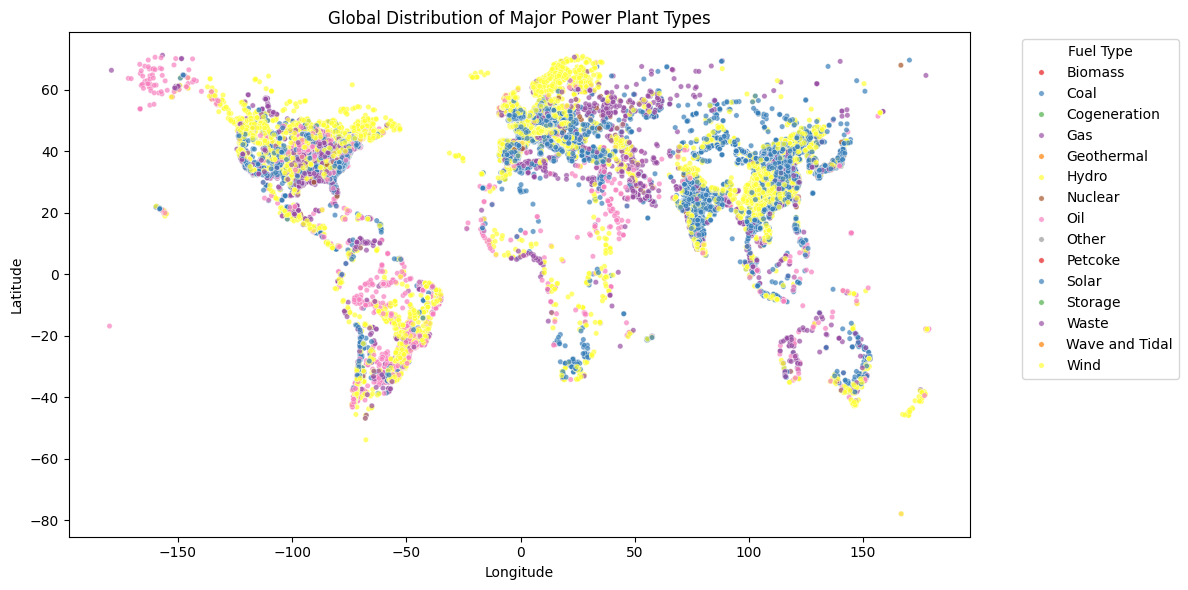

In [88]:
# Advanced Visualization: Global Distribution – Latitude vs Longitude

df_main = df2[df2['primary_fuel'].isin(main_fuels)]

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_main, x='longitude', y='latitude', hue='primary_fuel', palette='Set1', alpha=0.7, s=15)
plt.title("Global Distribution of Major Power Plant Types")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

The global distribution of power plants reflects geographical conditions, natural resources, and energy policies.

Traditional technologies are concentrated in industrialized regions (mainly China and the USA) and typically operate in large, centralized facilities.

In contrast, solar and wind power are more dispersed, as they depend on local natural resources and are developed through many smaller plants. There is a gradual transition toward a more diversified and distributed energy system.

In [86]:
# Ownership – Largest Private Actors

owner_counts = df.pivot_table(index='owner', values='capacity_mw', aggfunc='count').sort_values(by='capacity_mw', ascending=False)
display(owner_counts.head(5))


owners_of_interest = [
    "Cypress Creek Renewables",
    "Lightsource Renewable Energy",
    "Sustainable Power Group  LLC"
]

df_filtered = df2[df2['owner'].isin(owners_of_interest)]

#  rows =owner, columns=primary_fuel, values=count  of plants
pivot_table = df_filtered.pivot_table(
    index=['owner','country_long'],
    columns='primary_fuel',
    values='capacity_mw',
    aggfunc='count',
    fill_value=0,
    observed=False
)

# Filter rows where there is at least one value > 0
pivot_nonzero = pivot_table[(pivot_table > 0).any(axis=1)]

display(pivot_nonzero)



,capacity_mw
owner,
Cypress Creek Renewables,185
Lightsource Renewable Energy,121
Sustainable Power Group LLC,93
Verbund,83
Pacific Gas & Electric Co.,81


,primary_fuel,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Waste,Wave and Tidal,Wind
owner,country_long,,,,,,,,,,,,,,,
Cypress Creek Renewables,United States of America,0,0,0,0,0,0,0,0,0,0,185,0,0,0,0
Lightsource Renewable Energy,United Kingdom,0,0,0,0,0,0,0,0,0,0,121,0,0,0,0
Sustainable Power Group LLC,United States of America,0,0,0,0,0,0,0,0,0,0,88,0,0,0,2


3 top owners are heavily specialized in solar energy, with a presence in the United States and the United Kingdom, suggesting that the exponential growth in the number of plants is driven by private actors focused on renewables.

Solar development appears to be progressing through many smaller but numerous installations.

# Final thougts
The global energy system reflects a transition: traditional technologies dominate in large, centralized plants in industrialized regions, while renewables (solar and wind) are growing rapidly through numerous small, dispersed installations, driven by private players in key markets in the Fist World.  It points to a more diversified and distributed energy mix, indicating a less concentrated and more sustainable energy future.